<a href="https://colab.research.google.com/github/rimshamushtaq738-lgtm/Netflix-data-analysis/blob/main/Copy_of_netflix_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Netflix Movies & TV Shows — Exploratory Data Analysis & Visualization***


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("/content/archive (4).zip")

In [6]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [7]:
df.shape


(8807, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [13]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visualization style
sns.set_theme(style="whitegrid")

# Create folder for saving visualizations
os.makedirs("visualizations", exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Keep a backup of the original dataset
df_original = df.copy()

print("Original dataset backed up successfully.")
print("Shape:", df.shape)

Original dataset backed up successfully.
Shape: (8807, 12)


In [15]:
# ==============================
# 2. MISSING VALUE ANALYSIS
# ==============================

missing = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage.round(2)
})

missing_report

,Missing Values,Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


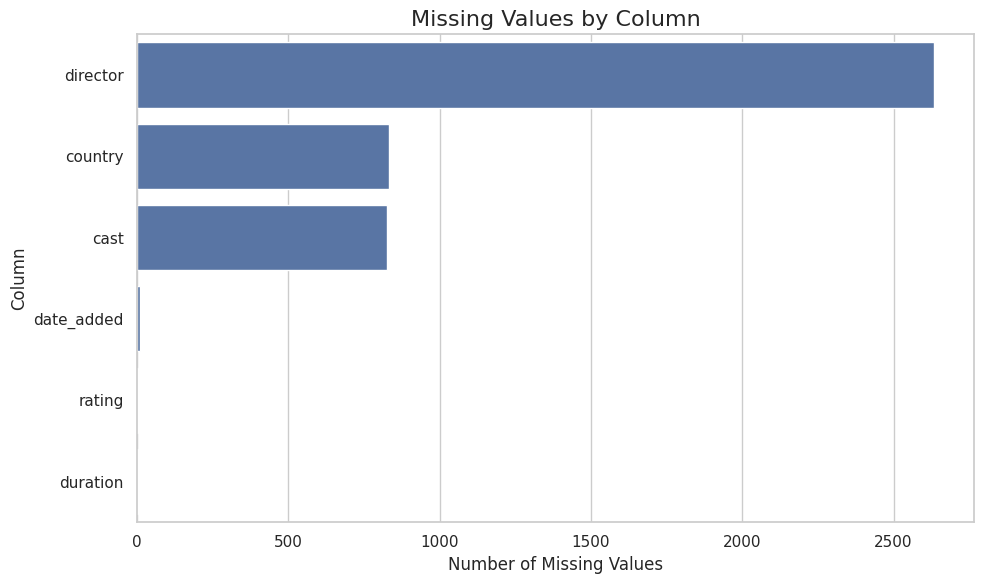

In [16]:
# ==============================
# MISSING VALUES VISUALIZATION
# ==============================

missing_plot = missing[missing > 0]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_plot.values,
    y=missing_plot.index
)

plt.title("Missing Values by Column", fontsize=16)
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.tight_layout()
plt.savefig("visualizations/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# ==============================
# 3. DATA CLEANING
# ==============================

# Fill missing categorical information
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

# Date is different because it should remain a date
# We will convert it properly instead of filling it with fake dates.

print("Missing categorical values handled.")

Missing categorical values handled.


In [19]:
# ==============================
# DATE CONVERSION
# ==============================

df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

print(df['date_added'].dtype)

datetime64[ns]


In [20]:
# ==============================
# FEATURE ENGINEERING - DATE
# ==============================

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,September
1,2021-09-24,2021.0,September
2,2021-09-24,2021.0,September
3,2021-09-24,2021.0,September
4,2021-09-24,2021.0,September


In [21]:
# ==============================
# 4. DURATION CLEANING
# ==============================

# Extract numeric duration
df['duration_value'] = pd.to_numeric(
    df['duration'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

# Movie duration in minutes
df['movie_duration_minutes'] = np.where(
    df['type'] == 'Movie',
    df['duration_value'],
    np.nan
)

# TV Show duration in seasons
df['tv_show_seasons'] = np.where(
    df['type'] == 'TV Show',
    df['duration_value'],
    np.nan
)

df[['type', 'duration', 'movie_duration_minutes', 'tv_show_seasons']].head(10)

,type,duration,movie_duration_minutes,tv_show_seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,NaN,2.0
2,TV Show,1 Season,NaN,1.0
3,TV Show,1 Season,NaN,1.0
4,TV Show,2 Seasons,NaN,2.0
5,TV Show,1 Season,NaN,1.0
6,Movie,91 min,91.0,NaN
7,Movie,125 min,125.0,NaN
8,TV Show,9 Seasons,NaN,9.0
9,Movie,104 min,104.0,NaN


In [ ]:
# Check the cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   show_id                 8807 non-null   object        
 1   type                    8807 non-null   object        
 2   title                   8807 non-null   object        
 3   director                8807 non-null   object        
 4   cast                    8807 non-null   object        
 5   country                 8807 non-null   object        
 6   date_added              8709 non-null   datetime64[ns]
 7   release_year            8807 non-null   int64         
 8   rating                  8807 non-null   object        
 9   duration                8804 non-null   object        
 10  listed_in               8807 non-null   object        
 11  description             8807 non-null   object        
 12  year_added              8709 non-null   float64 

In [22]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,3


In [23]:
# ==============================
# DUPLICATE CHECK
# ==============================

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [24]:
# ==============================
# FINAL DATASET SUMMARY
# ==============================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Movies:", (df['type'] == 'Movie').sum())
print("TV Shows:", (df['type'] == 'TV Show').sum())

Rows: 8807
Columns: 17
Movies: 6131
TV Shows: 2676


***EDA VISUALIZATION***

In [ ]:
# 📊 Exploratory Data Analysis & Visualization

This section explores Netflix's content catalog through statistical analysis and
data visualization. The analysis focuses on content types, countries, ratings,
genres, release trends, movie durations, TV show seasons, and relationships
between selected numerical variables.

All visualizations use a consistent professional visual theme to improve
readability and analytical presentation.

In [25]:
# ==========================================
# PROFESSIONAL NETFLIX VISUALIZATION THEME
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Professional Netflix-inspired color palette
NETFLIX_RED = "#E50914"
DARK = "#221F1F"
BURGUNDY = "#B20710"
GRAY = "#6B6B6B"
LIGHT_GRAY = "#E5E5E5"
CREAM = "#F5F5F1"

# General visualization settings
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.edgecolor": "#D0D0D0",
    "axes.labelcolor": DARK,
    "axes.titlecolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "font.size": 11,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 120
})

print("Professional visualization theme activated!")

Professional visualization theme activated!


In [26]:
# Movies vs TV Shows

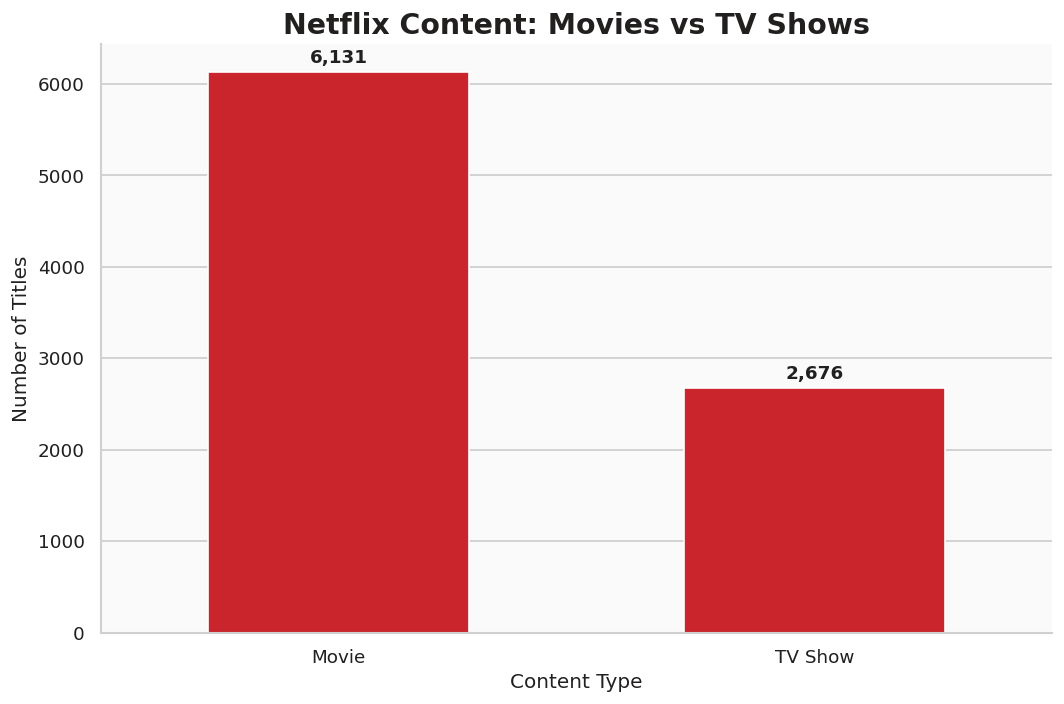

In [ ]:
# ==========================================
# VISUALIZATION 1
# MOVIES VS TV SHOWS
# ==========================================

type_counts = df["type"].value_counts()

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=type_counts.index,
    y=type_counts.values,
    color=NETFLIX_RED,
    width=0.55
)

plt.title("Netflix Content: Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

# Add values on bars
for i, value in enumerate(type_counts.values):
    ax.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center",
        fontweight="bold",
        color=DARK
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/01_content_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Content Percentage

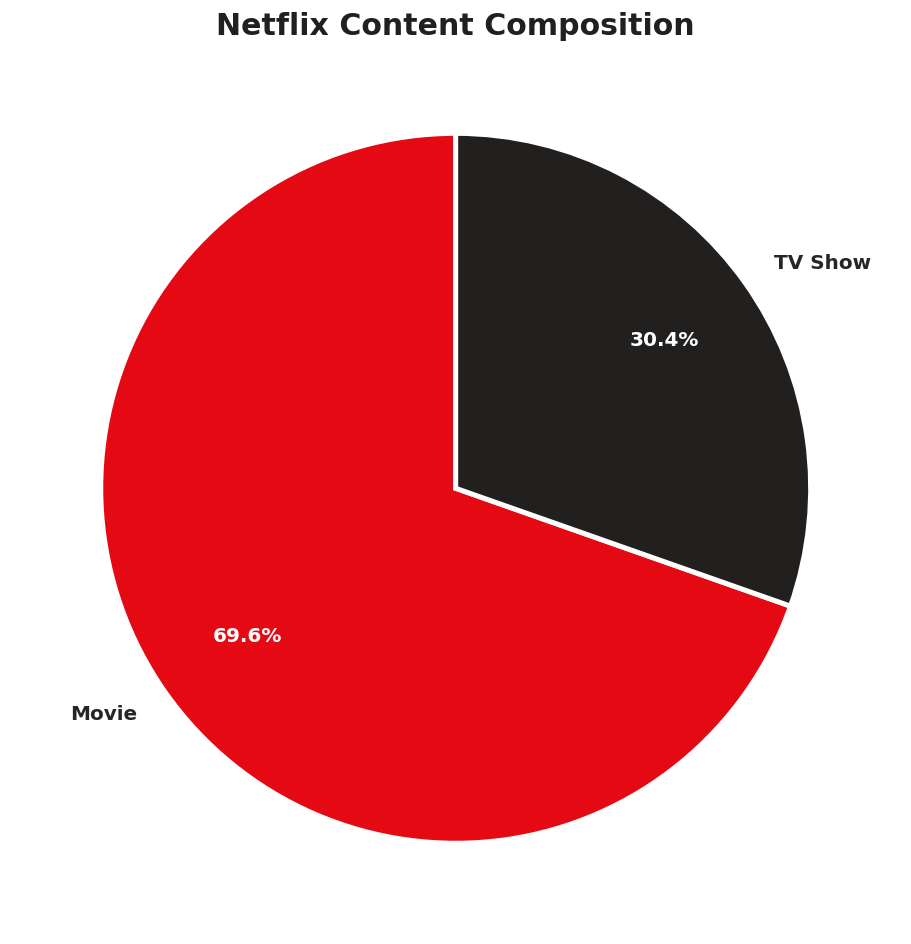

In [ ]:
# ==========================================
# VISUALIZATION 2
# CONTENT TYPE PERCENTAGE
# ==========================================

type_counts = df["type"].value_counts()

colors = [NETFLIX_RED, DARK]

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.72,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 3
    }
)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight("bold")

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(12)

plt.title(
    "Netflix Content Composition",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "visualizations/02_content_type_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Top 10 Countries

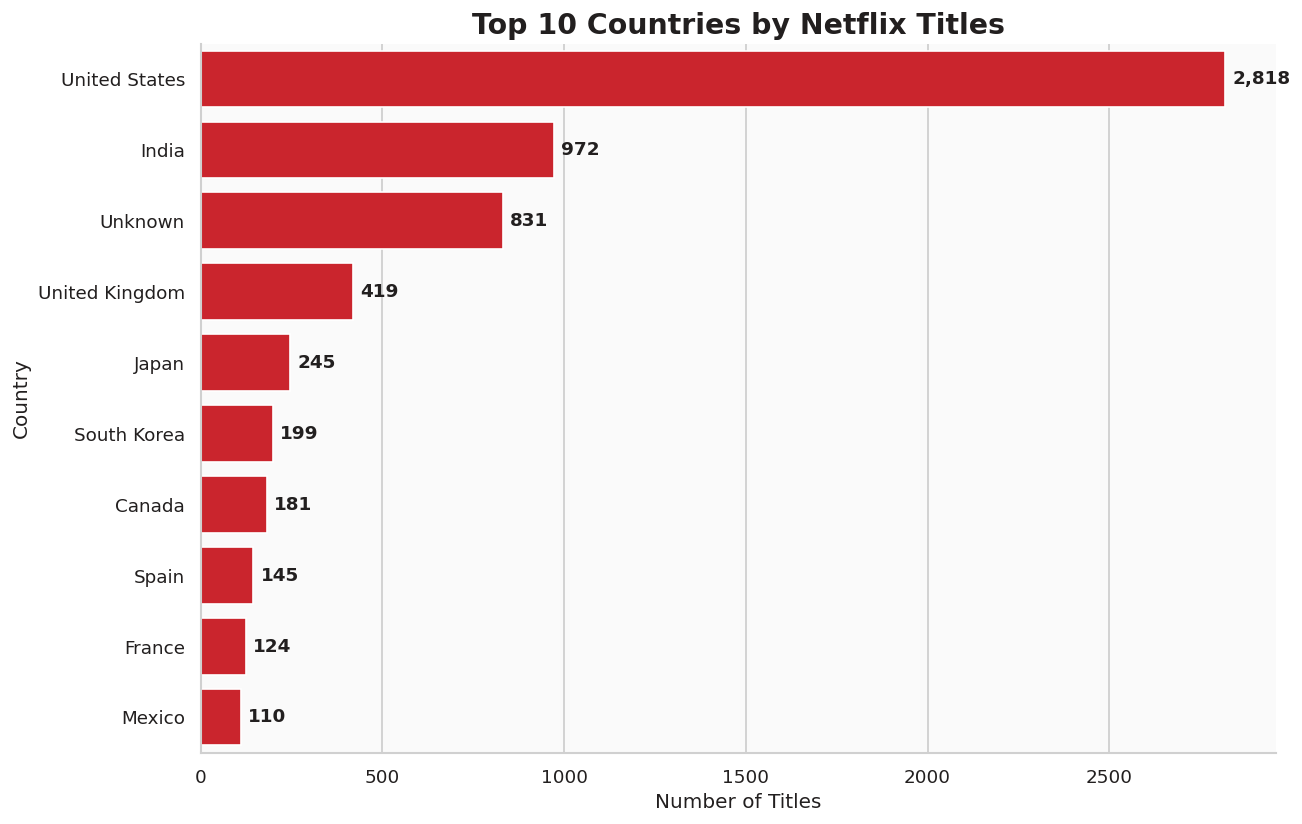

In [ ]:
# ==========================================
# VISUALIZATION 3
# TOP 10 COUNTRIES
# ==========================================

country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    color=NETFLIX_RED
)

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

# Add values
for i, value in enumerate(country_counts.values):
    ax.text(
        value + 20,
        i,
        f"{value:,}",
        va="center",
        fontweight="bold",
        color=DARK
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/03_top_10_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# Rating Distribution

/tmp/ipykernel_4876/47736748.py:21: UserWarning: 
The palette list has fewer values (8) than needed (18) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


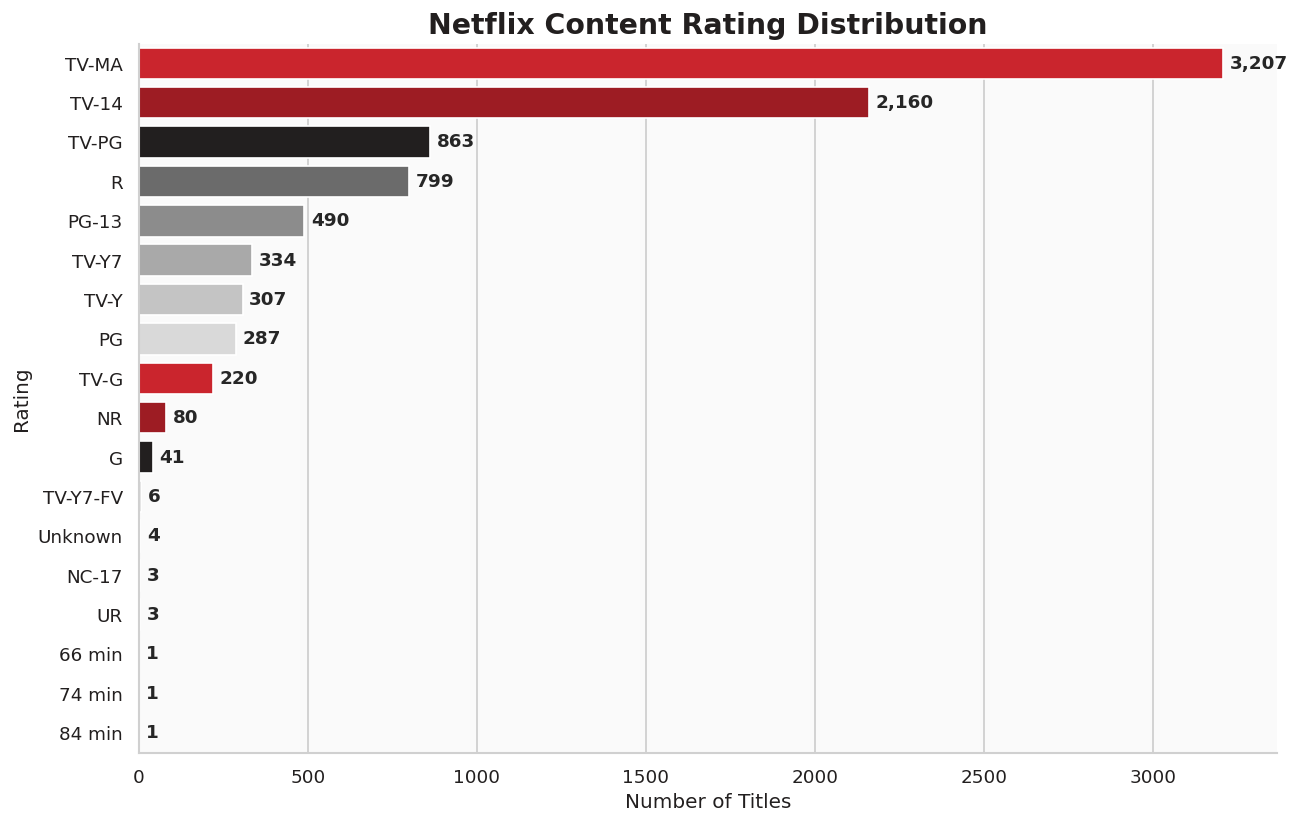

In [30]:
# ==========================================
# VISUALIZATION 4
# RATING DISTRIBUTION
# ==========================================

rating_counts = df["rating"].value_counts()

rating_palette = [
    "#E50914",
    "#B20710",
    "#221F1F",
    "#6B6B6B",
    "#8C8C8C",
    "#A9A9A9",
    "#C4C4C4",
    "#D9D9D9"
]

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    palette=rating_palette[:len(rating_counts)],
    hue=rating_counts.index,
    legend=False
)

plt.title("Netflix Content Rating Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

for i, value in enumerate(rating_counts.values):
    ax.text(
        value + 20,
        i,
        f"{value:,}",
        va="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/04_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# Release Year Distribution

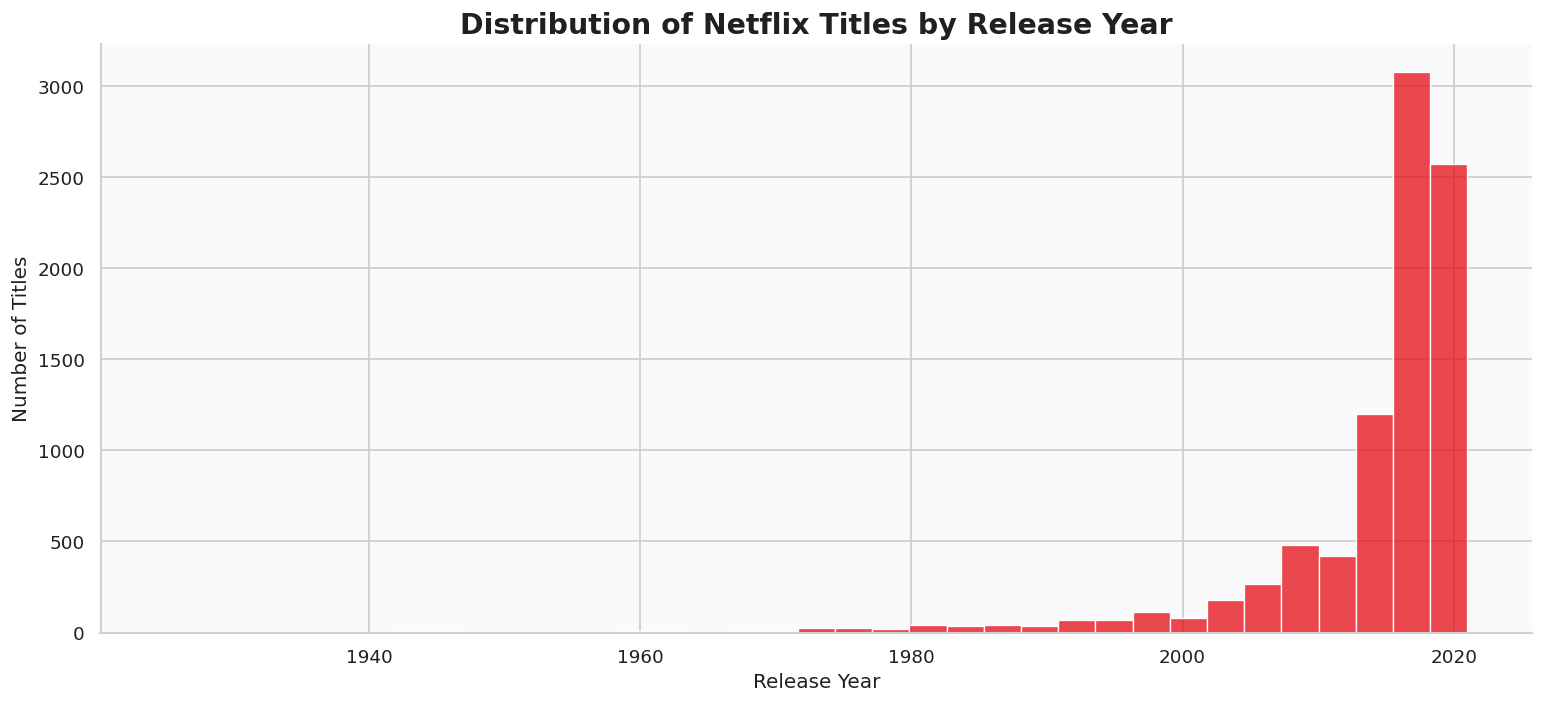

In [32]:
# ==========================================
# VISUALIZATION 5
# RELEASE YEAR DISTRIBUTION
# ==========================================

plt.figure(figsize=(13, 6))

sns.histplot(
    data=df,
    x="release_year",
    bins=35,
    color=NETFLIX_RED,
    edgecolor="white",
    linewidth=0.8
)

plt.title("Distribution of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/05_release_year_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Release Trend

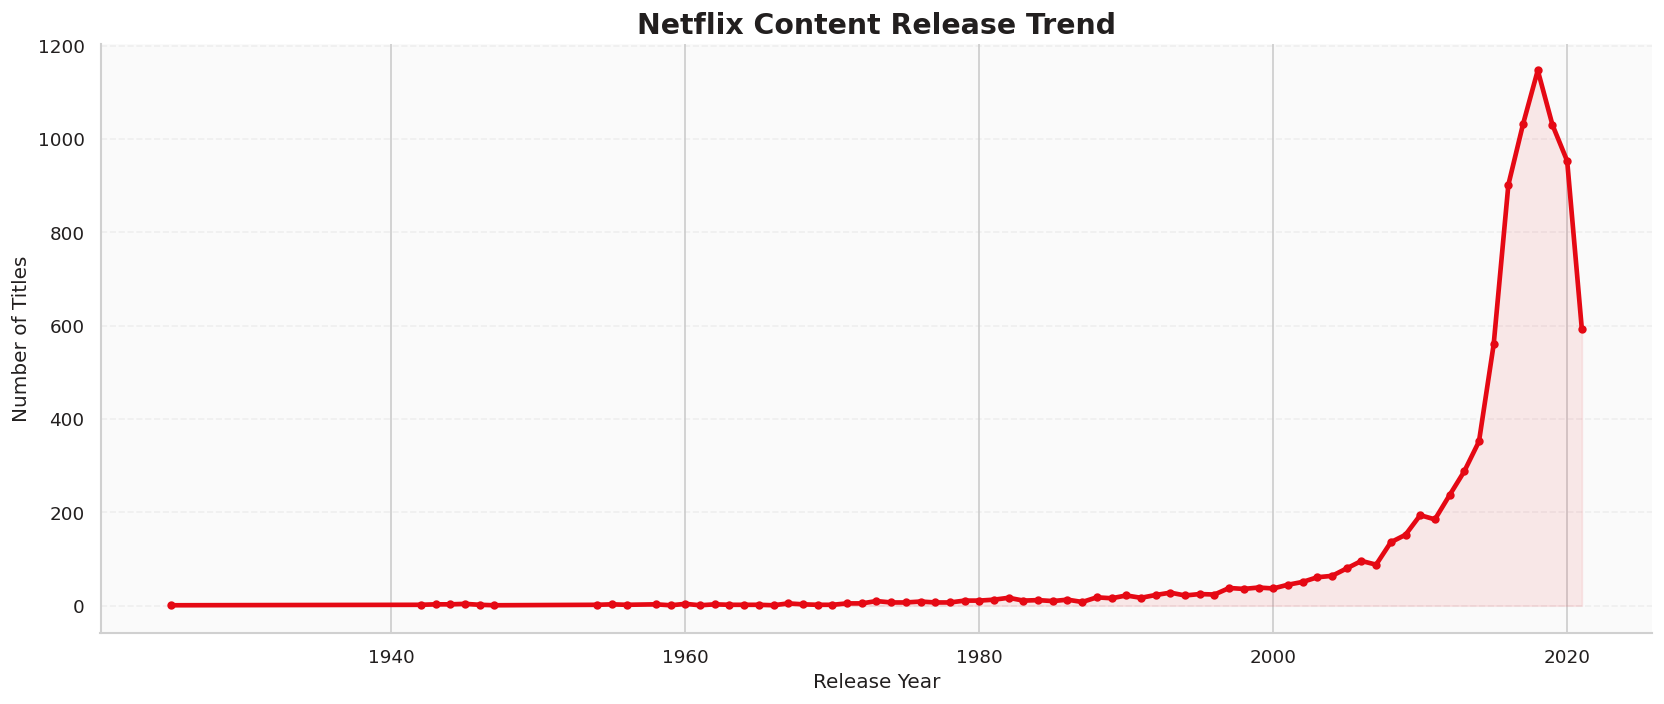

In [34]:
# ==========================================
# VISUALIZATION 6
# RELEASE TREND
# ==========================================

release_trend = df.groupby("release_year").size()

plt.figure(figsize=(14, 6))

plt.plot(
    release_trend.index,
    release_trend.values,
    color=NETFLIX_RED,
    linewidth=2.8,
    marker="o",
    markersize=4
)

plt.fill_between(
    release_trend.index,
    release_trend.values,
    alpha=0.08,
    color=NETFLIX_RED
)

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/06_release_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# Content Added to Netflix

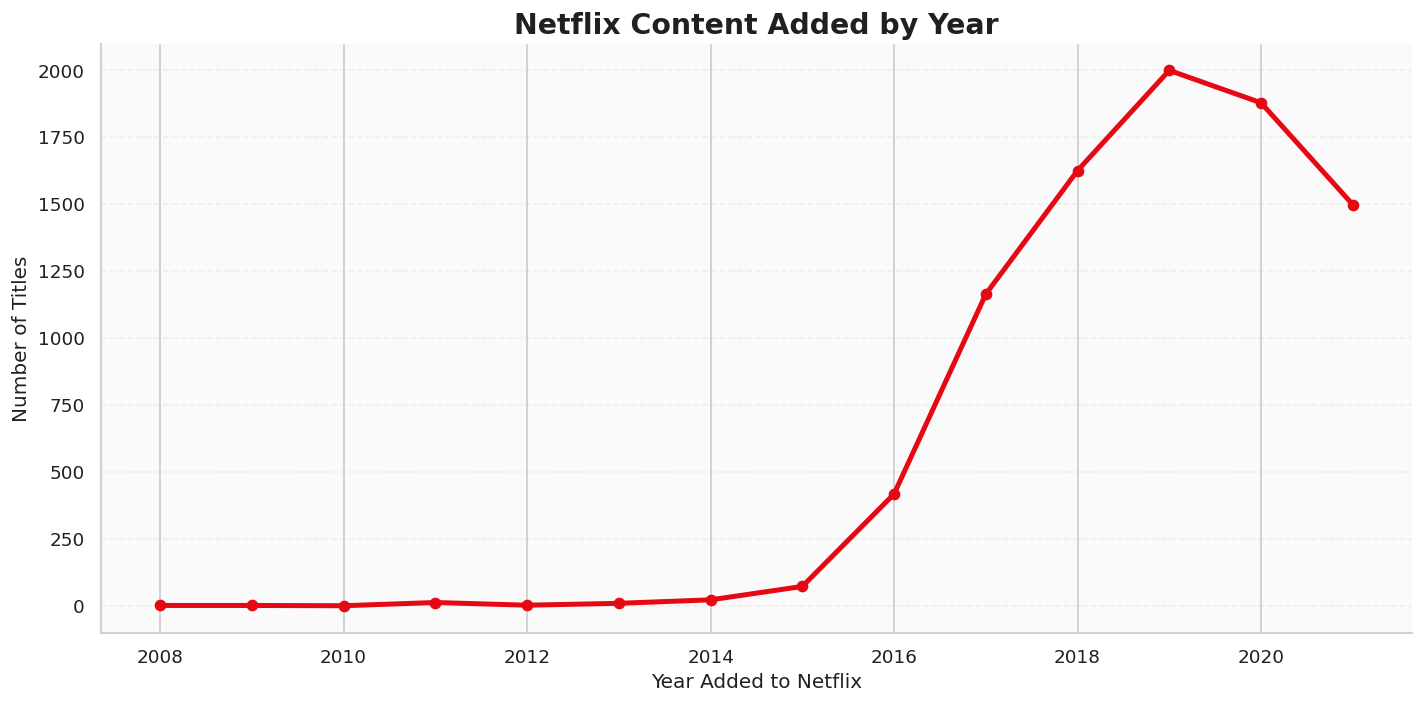

In [36]:
# ==========================================
# VISUALIZATION 7
# CONTENT ADDED BY YEAR
# ==========================================

added_by_year = (
    df.dropna(subset=["year_added"])
      .groupby("year_added")
      .size()
)

plt.figure(figsize=(12, 6))

plt.plot(
    added_by_year.index,
    added_by_year.values,
    color=NETFLIX_RED,
    linewidth=3,
    marker="o",
    markersize=6
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/07_content_added_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Top Genres

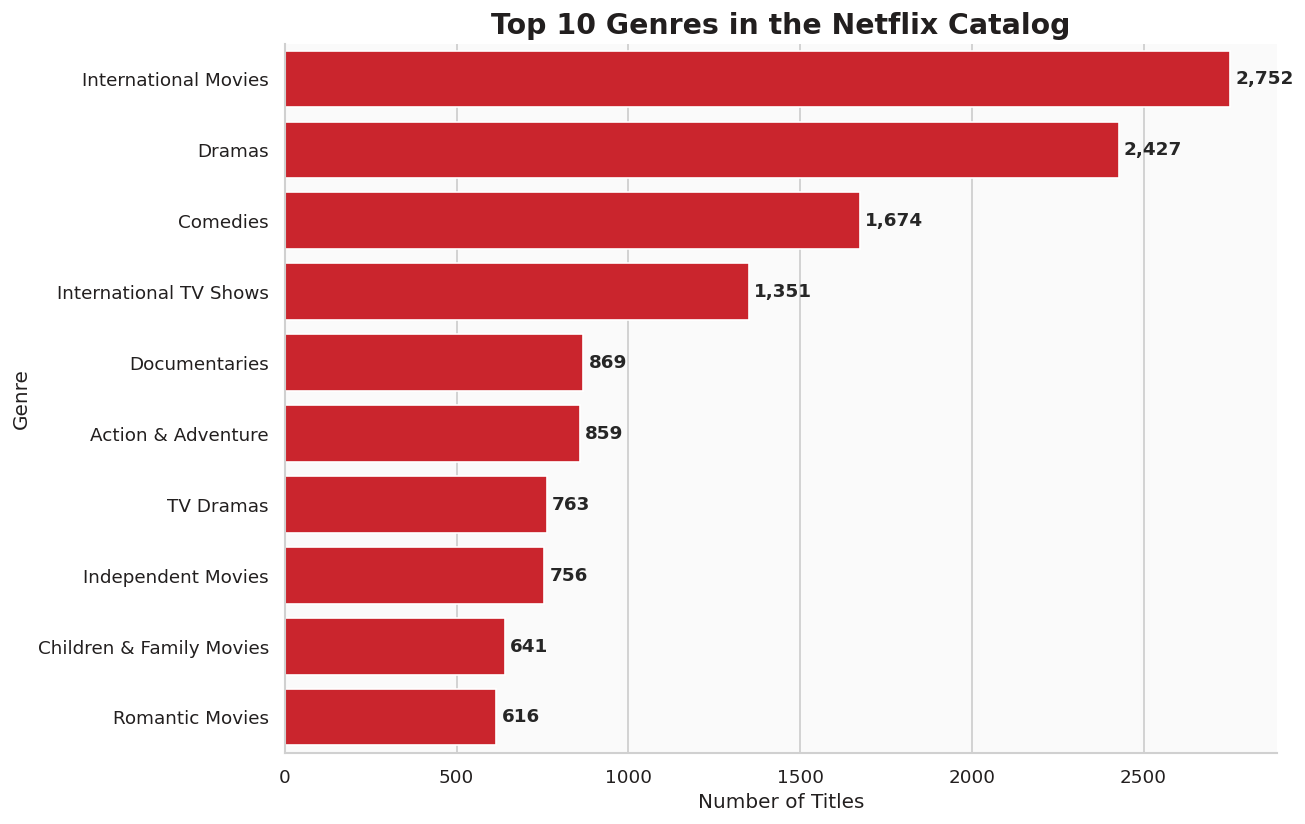

In [38]:
# ==========================================
# VISUALIZATION 8
# TOP 10 GENRES
# ==========================================

genres = df['listed_in'].str.split(', ').explode()
genre_counts = genres.value_counts().head(10)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    color=NETFLIX_RED
)

plt.title("Top 10 Genres in the Netflix Catalog")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

for i, value in enumerate(genre_counts.values):
    ax.text(
        value + 15,
        i,
        f"{value:,}",
        va="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/08_top_10_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Movie Duration

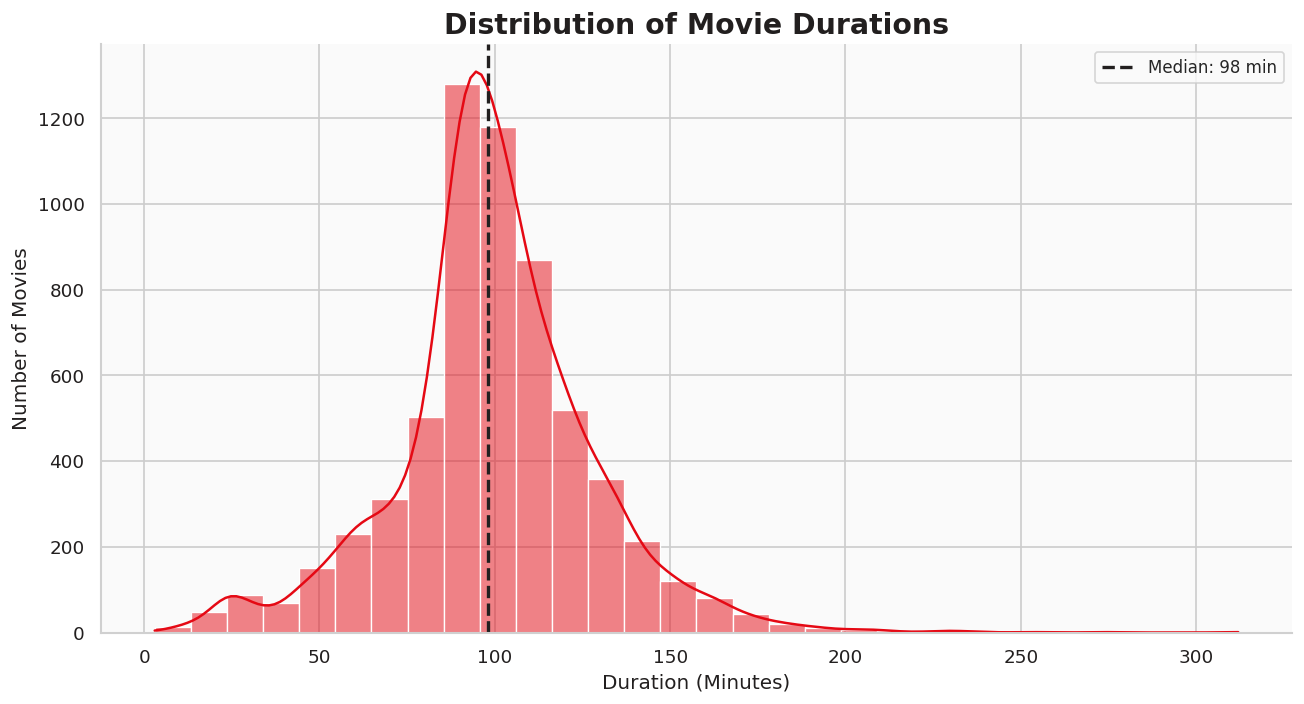

In [40]:
# ==========================================
# VISUALIZATION 9
# MOVIE DURATION DISTRIBUTION
# ==========================================

movie_data = df[df['type'] == 'Movie'].copy()
movie_data.dropna(subset=['movie_duration_minutes'], inplace=True)

plt.figure(figsize=(11, 6))

sns.histplot(
    data=movie_data,
    x="movie_duration_minutes",
    bins=30,
    kde=True,
    color=NETFLIX_RED,
    edgecolor="white",
    linewidth=0.8
)

# Median line
median_duration = movie_data["movie_duration_minutes"].median()

plt.axvline(
    median_duration,
    color=DARK,
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_duration:.0f} min"
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.legend()
sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/09_movie_duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
# Movie Duration Box Plot

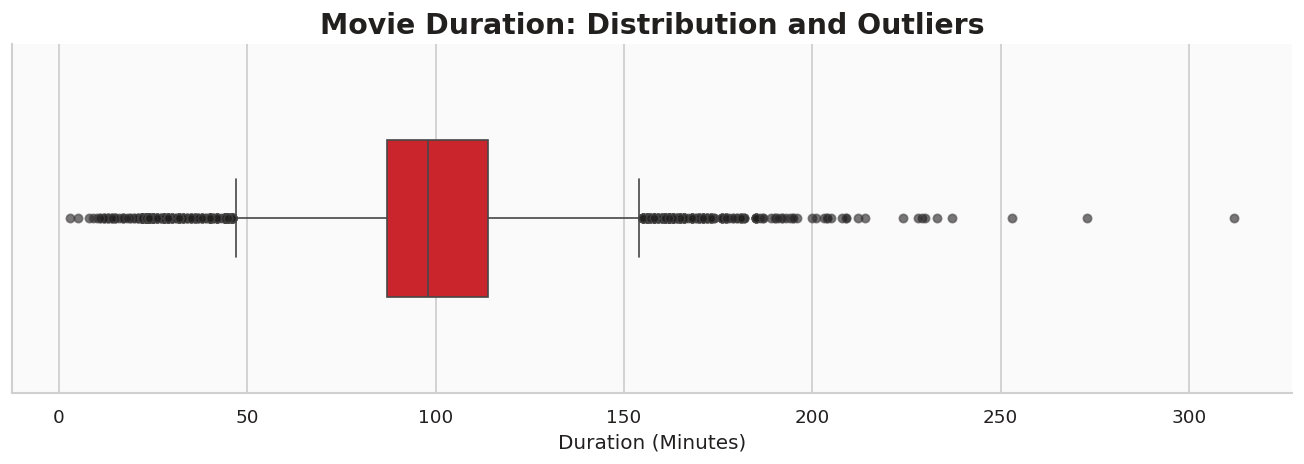

In [42]:
# ==========================================
# VISUALIZATION 10
# MOVIE DURATION OUTLIERS
# ==========================================

plt.figure(figsize=(11, 4))

sns.boxplot(
    x=movie_data["movie_duration_minutes"],
    color=NETFLIX_RED,
    width=0.45,
    flierprops={
        "marker": "o",
        "markerfacecolor": DARK,
        "markersize": 5,
        "alpha": 0.6
    }
)

plt.title("Movie Duration: Distribution and Outliers")
plt.xlabel("Duration (Minutes)")

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/10_movie_duration_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
# TV Show Seasons

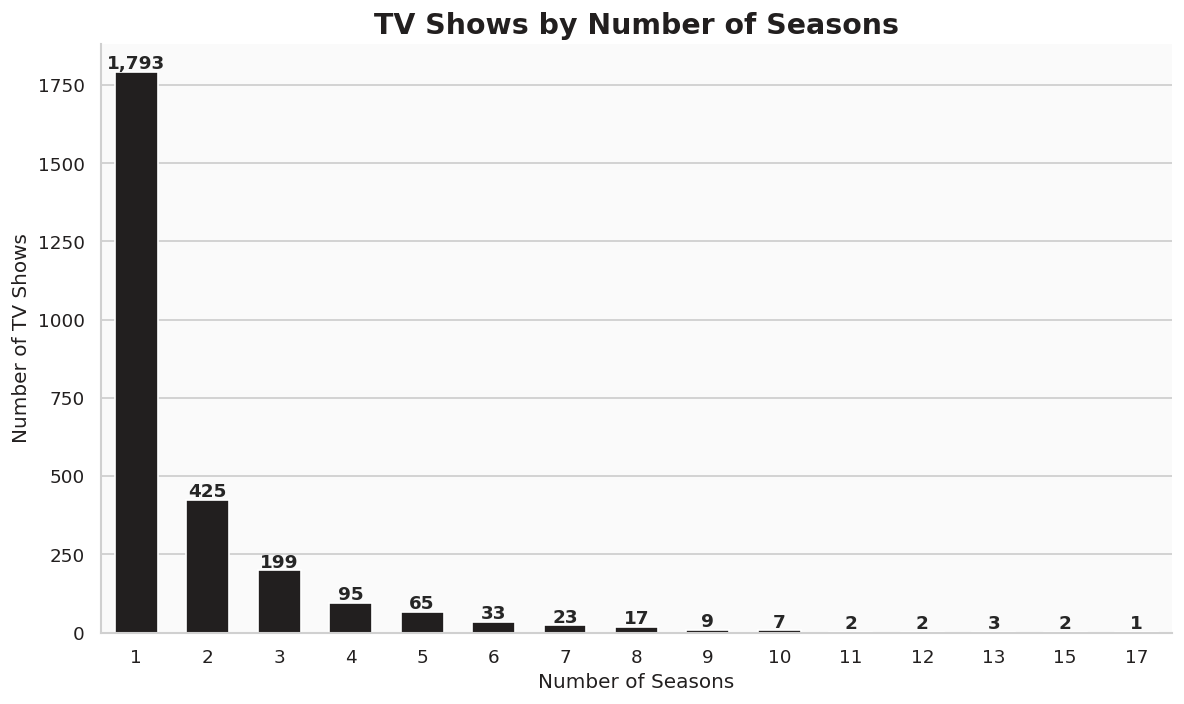

In [44]:
# ==========================================
# VISUALIZATION 11
# TV SHOW SEASONS
# ==========================================

tv_data = df[df['type'] == 'TV Show'].copy()
tv_data.dropna(subset=['tv_show_seasons'], inplace=True)

season_counts = tv_data["tv_show_seasons"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=season_counts.index.astype(int),
    y=season_counts.values,
    color=DARK,
    width=0.6
)

plt.title("TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

for i, value in enumerate(season_counts.values):
    ax.text(
        i,
        value + 10,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/11_tv_show_seasons.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# Rating vs Content Type

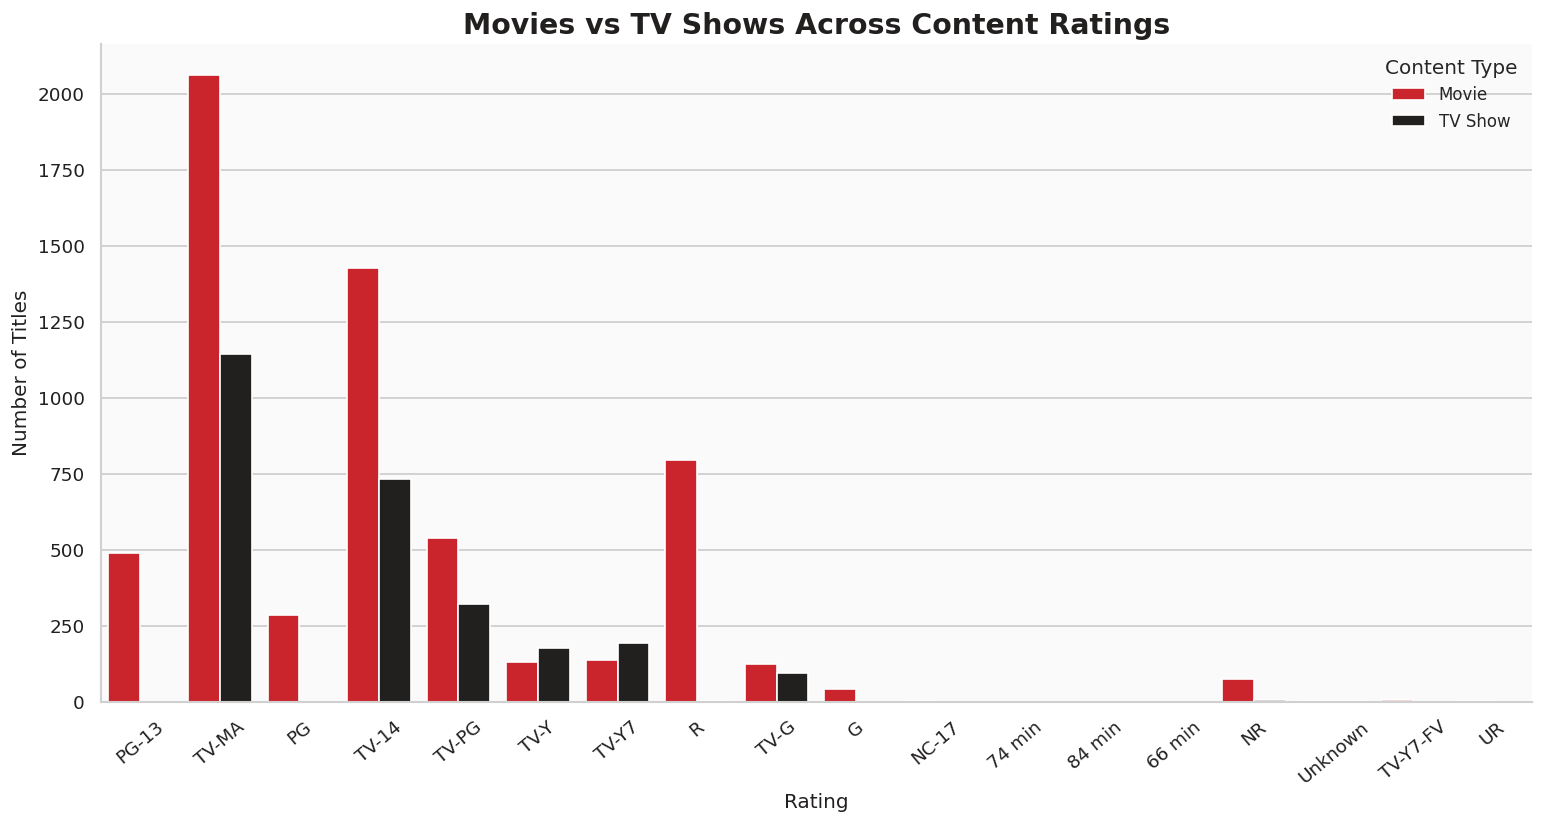

In [46]:
# ==========================================
# VISUALIZATION 12
# RATING VS CONTENT TYPE
# ==========================================

plt.figure(figsize=(13, 7))

sns.countplot(
    data=df,
    x="rating",
    hue="type",
    palette={
        "Movie": NETFLIX_RED,
        "TV Show": DARK
    }
)

plt.title("Movies vs TV Shows Across Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=40)

plt.legend(
    title="Content Type",
    frameon=False
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/12_rating_vs_content_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# Movies vs TV Shows Over Years

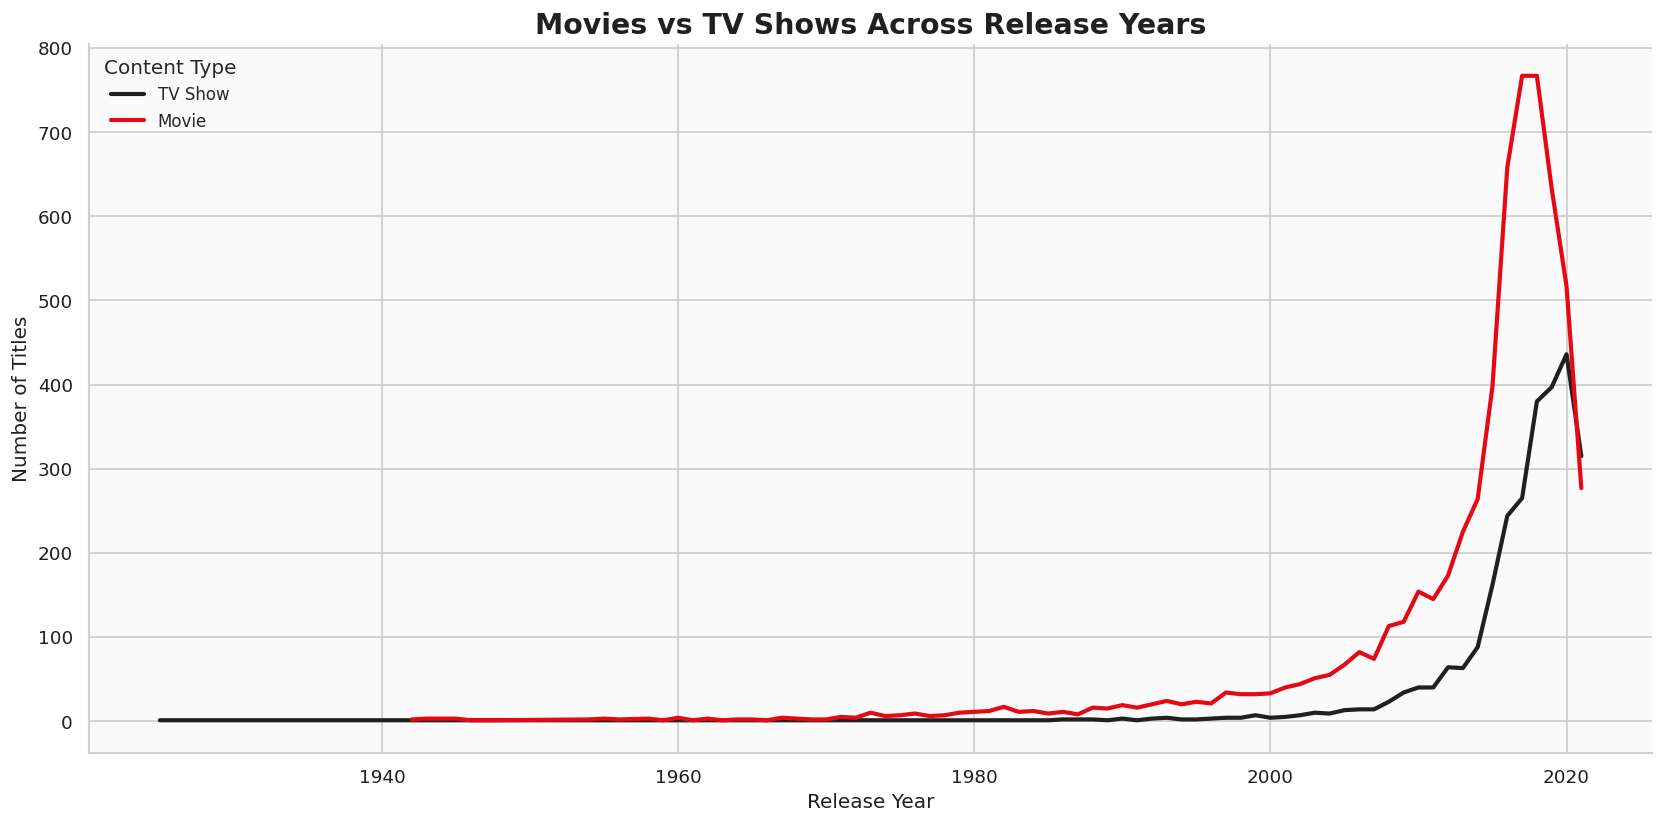

In [48]:
# ==========================================
# VISUALIZATION 13
# MOVIES VS TV SHOWS OVER YEARS
# ==========================================

year_type = (
    df.groupby(["release_year", "type"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=year_type,
    x="release_year",
    y="count",
    hue="type",
    palette={
        "Movie": NETFLIX_RED,
        "TV Show": DARK
    },
    linewidth=2.5
)

plt.title("Movies vs TV Shows Across Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend(
    title="Content Type",
    frameon=False
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/13_movies_vs_tv_over_years.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# Top Directors

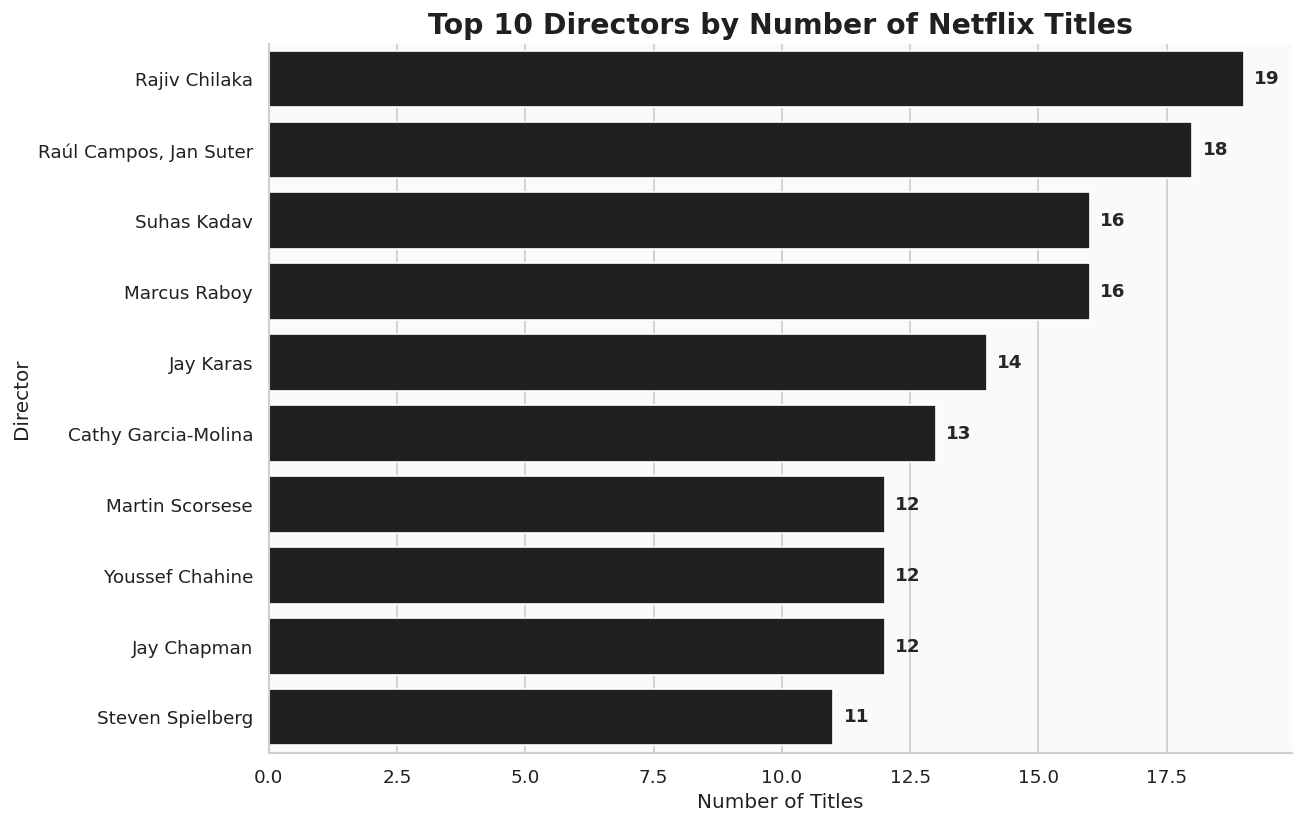

In [50]:
# ==========================================
# VISUALIZATION 14
# TOP DIRECTORS
# ==========================================

director_counts = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=director_counts.values,
    y=director_counts.index,
    color=DARK
)

plt.title("Top 10 Directors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

for i, value in enumerate(director_counts.values):
    ax.text(
        value + 0.2,
        i,
        f"{value:,}",
        va="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/14_top_10_directors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
# Countries vs Content Type

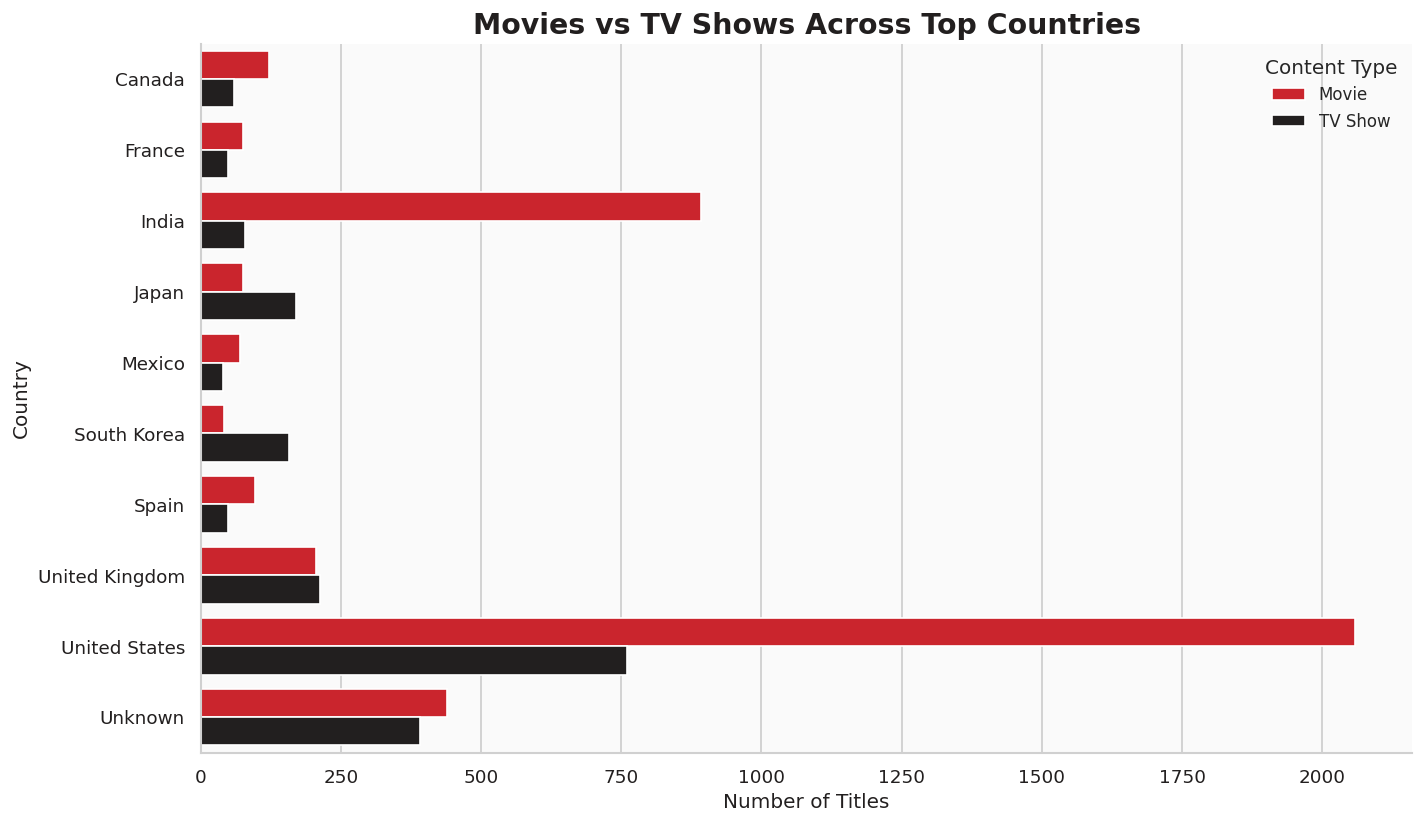

In [54]:
# ==========================================
# VISUALIZATION 15
# COUNTRY VS CONTENT TYPE
# ==========================================

# Re-defining country_counts to ensure it's available
country_counts = df['country'].value_counts().head(10)

top_countries = country_counts.index.tolist()
country_type = (
    df[df['country'].isin(top_countries)]
    .groupby(['country', 'type'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_type,
    x="count",
    y="country",
    hue="type",
    palette={
        "Movie": NETFLIX_RED,
        "TV Show": DARK
    }
)

plt.title("Movies vs TV Shows Across Top Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.legend(
    title="Content Type",
    frameon=False
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/15_country_vs_content_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Monthly Additions

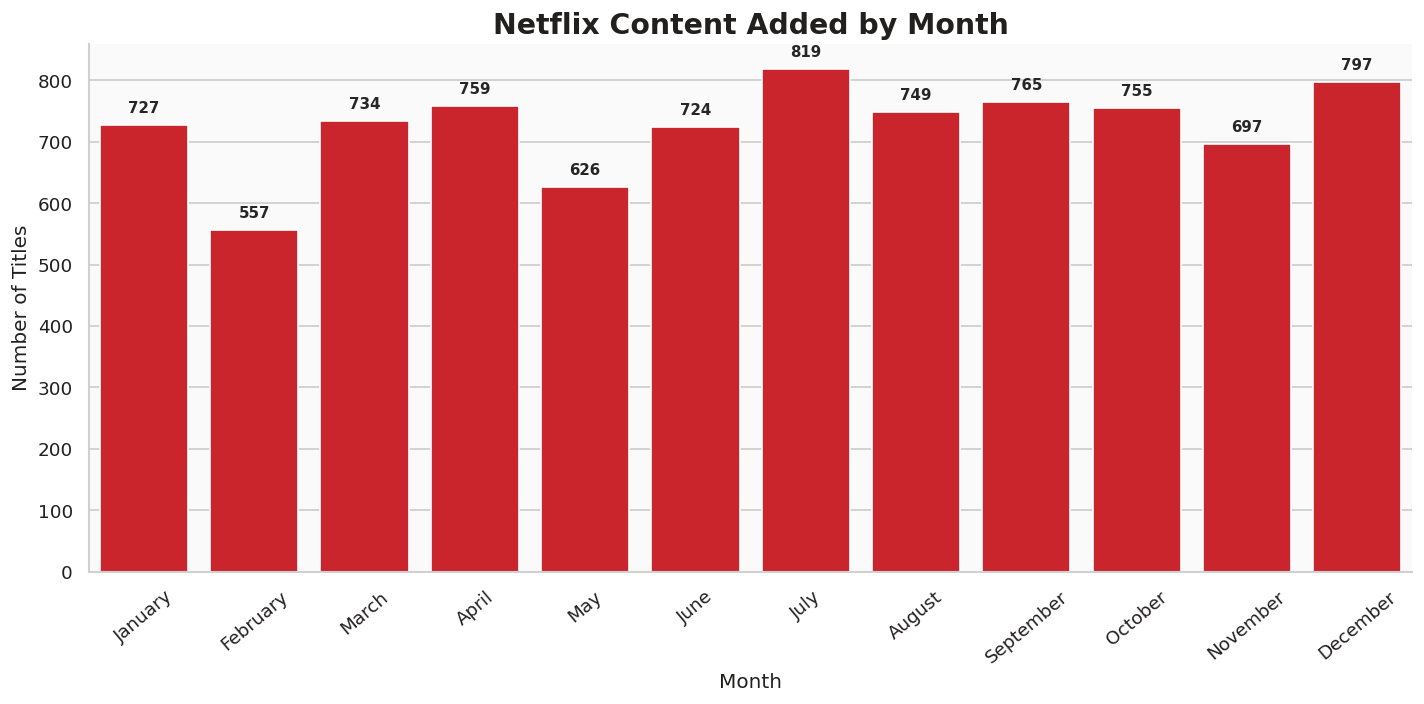

In [55]:
# ==========================================
# VISUALIZATION 16
# MONTHLY CONTENT ADDITIONS
# ==========================================

# Define the correct order of months
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Calculate monthly additions and sort by month_order
monthly_added = (
    df.dropna(subset=['month_added'])['month_added']
    .value_counts()
    .reindex(month_order)
    .fillna(0)
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=monthly_added.index,
    y=monthly_added.values,
    color=NETFLIX_RED
)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=40)

for i, value in enumerate(monthly_added.values):
    ax.text(
        i,
        value + 20,
        f"{int(value):,}", # Convert to int for cleaner display
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/16_monthly_content_added.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# Genres vs Content Type

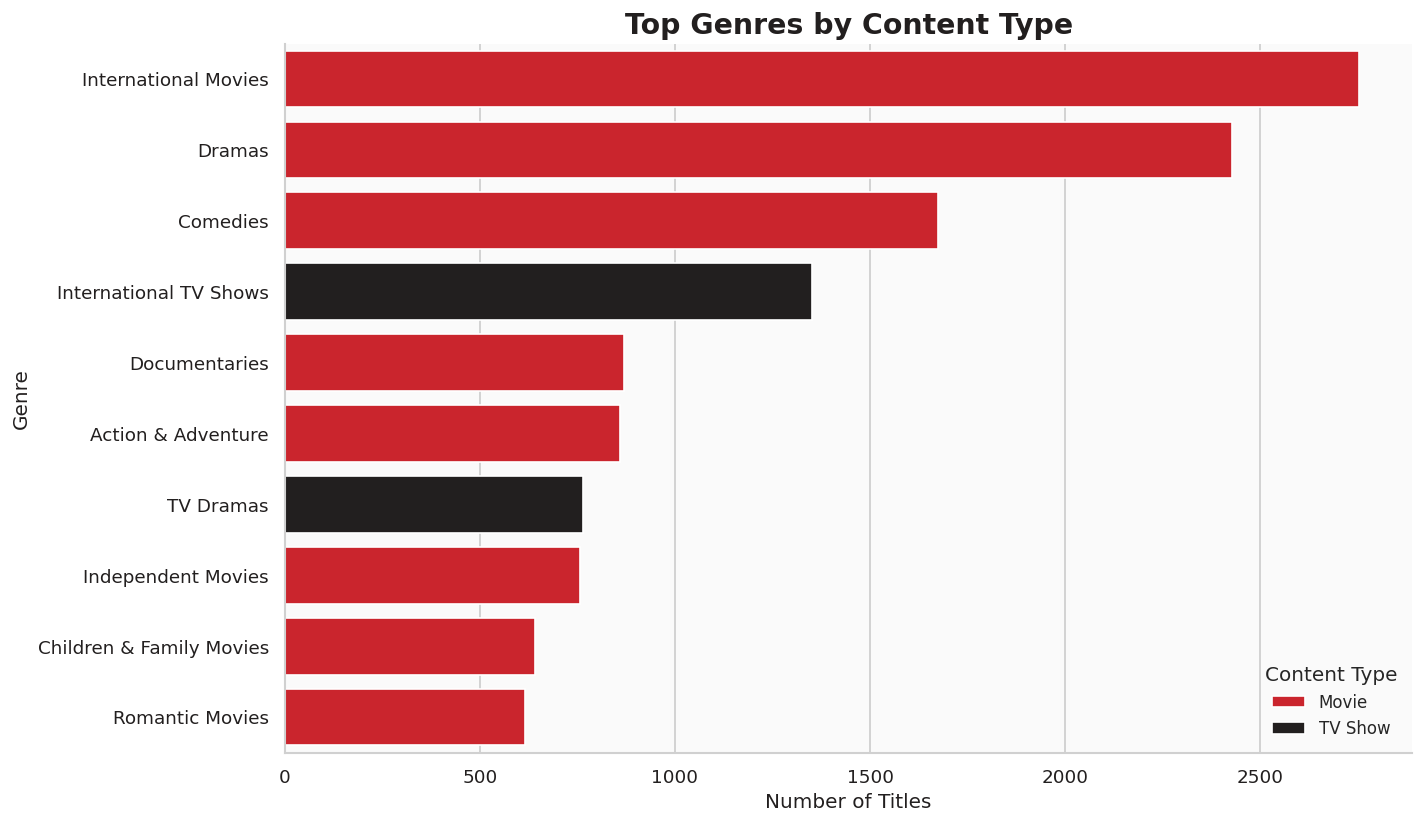

In [57]:
# ==========================================
# VISUALIZATION 17
# GENRE VS CONTENT TYPE
# ==========================================

# Split 'listed_in' into individual genres and explode them into separate rows
genres_df = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')

# Calculate counts for each genre and content type
genre_type_counts = (
    genres_df.groupby(['genre', 'type'])
    .size()
    .reset_index(name='count')
)

# Use the pre-calculated top 10 genres from VISUALIZATION 8 to filter
top_10_genres_list = genre_counts.index.tolist()

# Filter genre_type_counts to include only the top 10 genres
genre_type = genre_type_counts[genre_type_counts['genre'].isin(top_10_genres_list)].copy()

# Ensure genres are ordered by their overall count for consistent plotting
genre_type['genre'] = pd.Categorical(
    genre_type['genre'],
    categories=top_10_genres_list,
    ordered=True
)
genre_type.sort_values(by=['genre', 'type'], inplace=True)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_type,
    x="count",
    y="genre",
    hue="type",
    palette={
        "Movie": NETFLIX_RED,
        "TV Show": DARK
    }
)

plt.title("Top Genres by Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.legend(
    title="Content Type",
    frameon=False
)

sns.despine()
plt.tight_layout()

plt.savefig(
    "visualizations/17_genre_vs_content_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# Correlation Heatmap

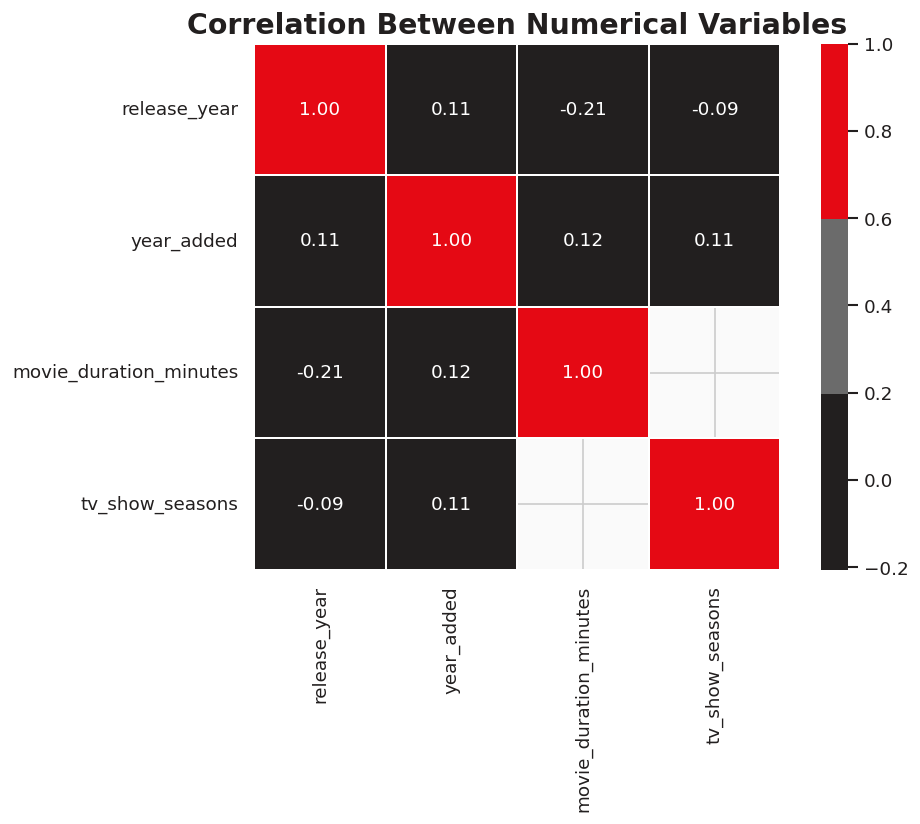

In [59]:
# ==========================================
# VISUALIZATION 18
# CORRELATION HEATMAP
# ==========================================

numeric_columns = [
    "release_year",
    "year_added",
    "movie_duration_minutes",
    "tv_show_seasons"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        ["#221F1F", "#6B6B6B", "#E50914"],
        as_cmap=True
    ),
    linewidths=1,
    linecolor="white",
    square=True
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()

plt.savefig(
    "visualizations/18_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# 🔎 Key Findings

The following section summarizes the major patterns and insights identified
from the exploratory analysis.